In [1]:
# Load images

import digiagro_helper_hsv as helper
from importlib import reload
reload(helper)
import torch
import numpy as np
import alvq
import lvq_p_train
reload(alvq)
reload(lvq_p_train)
from tqdm import tqdm
import matplotlib.pyplot as plt

img_dir = '../../Croptimal/resnet/train'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('256_class_0', 1.0)],
    # Class 1
    [('256_class_1', 1.0)]]

n_classes = len(class_subdirs)
global_imgs = helper.read_imgs(img_dir, class_subdirs)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')

Loaded 2258 images for class 0
Loaded 1390 images for class 1


100%|██████████| 2500/2500 [00:11<00:00, 220.20it/s]


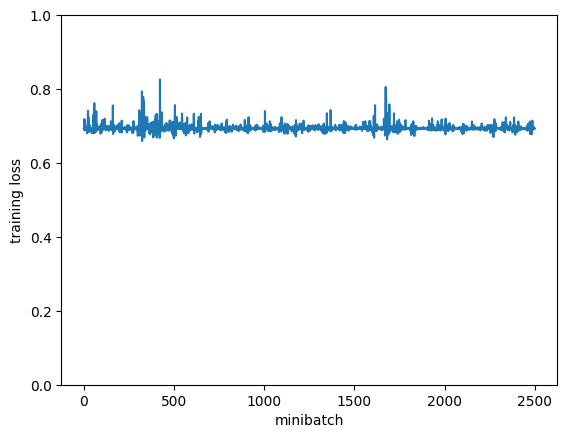

In [38]:
import digiagro_helper_hsv as helper
from importlib import reload
reload(helper)
reload(alvq)
reload(lvq_p_train)

# Check how many minibatches are needed to train

minibatch_sz = 50
n_minibatches = 2500

imgs_train, imgs_val = helper.xval(global_imgs)
train_loader = helper.data_loader(imgs_train, minibatch_sz)

mu, std = helper.feats_mean_std(train_loader, n_minibatches // 10)
mu = torch.from_numpy(mu)
std = torch.from_numpy(std)

n_feats = mu.shape[0]
init_protos = torch.from_numpy(np.ones((2, n_feats), dtype=np.float32))

net = alvq.alvq_net(n_feats, init_protos, False, mu, std)
lvq = lvq_p_train.lvq_p_train(net, lr=0.001)

losses = np.empty(n_minibatches)

for batch_nr in tqdm(range(n_minibatches)):
    X, y = next(train_loader)
    X = torch.from_numpy(X)
    y = torch.from_numpy(y)        
    losses[batch_nr] = lvq.train(X, y)
    if np.isnan(losses[batch_nr]):
        print("NaN detected")
        print(lvq.net.protos)
        break

# print(losses)
plt.plot(losses)
plt.ylim(0,1)
plt.xlabel('minibatch')
plt.ylabel('training loss');

In [ ]:
# Train probabilistic angular LVQ

minibatch_sz = 5000
n_minibatches = 250
# Increase to decrease the variance in the average validation accuracy
n_runs = 10
val_accs = np.zeros(n_runs)

for data_split_nr in tqdm(range(n_runs)):
    imgs_train, imgs_val = helper.xval(global_imgs)

    train_loader = helper.data_loader(imgs_train, minibatch_sz)
   
    mu, std = helper.feats_mean_std(train_loader, n_minibatches // 10)

    mu = torch.from_numpy(mu)
    std = torch.from_numpy(std)

    n_feats = mu.shape[0]
    init_protos = torch.from_numpy(np.ones((2, n_feats), dtype=np.float32))
    
    net = alvq.alvq_net(n_feats, init_protos, False, mu, std)
    lvq = lvq_p_train.lvq_p_train(net, lr=0.001)
    
    for batch_nr in range(n_minibatches):
        X, y = next(train_loader)
        X = torch.from_numpy(X)
        y = torch.from_numpy(y)        
        lvq.train(X, y)
        
    val_loader = helper.data_loader(imgs_val, minibatch_sz)    
    X, y = next(val_loader) # just 1 minibatch    

    X = torch.from_numpy(X)
    y = torch.from_numpy(y)
    y_pred = lvq.inference(X)
    val_accs[data_split_nr] = (y_pred == y).sum() / y.shape[0]

print(f'avg val acc: {val_accs.mean():.4f} ± {val_accs.std():.4f}')

100%|██████████| 10/10 [02:16<00:00, 13.67s/it]

avg val acc: 0.5418 ± 0.0172


In [8]:
# Train on all images

minibatch_sz = 5000
n_minibatches = 250

train_loader = helper.data_loader(global_imgs, minibatch_sz)
   
mu, std = helper.feats_mean_std(train_loader, n_minibatches // 10)

mu = torch.from_numpy(mu)
std = torch.from_numpy(std)

n_feats = mu.shape[0]
init_protos = torch.from_numpy(np.ones((2, n_feats), dtype=np.float32))

net = alvq.alvq_net(n_feats, init_protos, False, mu, std)
lvq = lvq_p_train.lvq_p_train(net, lr=0.0001)
    
for batch_nr in range(n_minibatches):
    X, y = next(train_loader)
    X = torch.from_numpy(X)
    y = torch.from_numpy(y)        
    lvq.train(X, y)

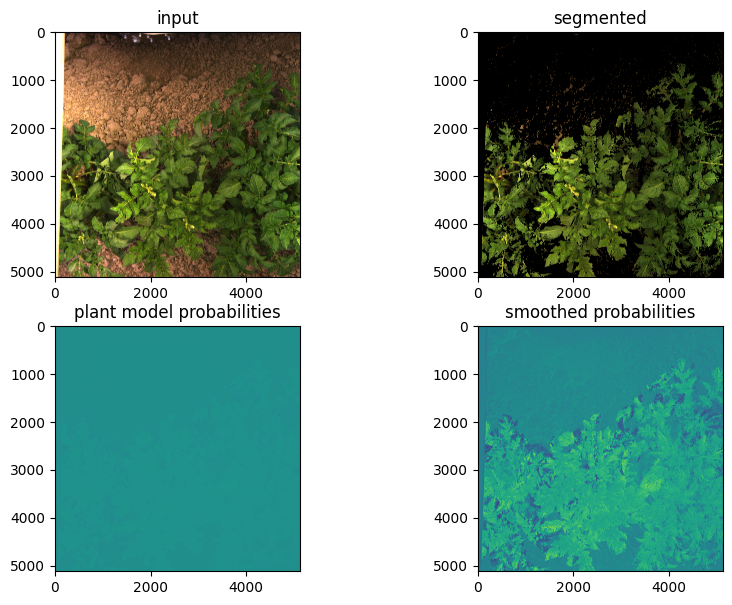

In [9]:
# Test image in the testing dataset

# Parameters

ds = 8            # downscale factor for probability smoothing
p_threshold = 0.5 # (average) probability threshold

import cv2
import skimage.io

img = skimage.io.imread("../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/test/4e8ef493-3884-4645-82c6-4291a576684d.png")

width = img.shape[1]
height = img.shape[0]

# probabilities
with torch.no_grad():
    scalar = net.probabilities(torch.from_numpy(img))

scalar = scalar[..., 1].reshape(img.shape[0:2]).detach()
scalar_orig = scalar
scalar = cv2.resize(scalar.numpy(), (width // ds, height // ds), interpolation=cv2.INTER_AREA)
scalar = cv2.resize(scalar, (width, height), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(2, 2, figsize=(10,7))
axes[0][0].imshow(img)
axes[0][0].set_title('input')
img2 = img.copy()
img2[scalar < p_threshold, :] = 0
axes[0][1].imshow(img2)
axes[0][1].set_title('segmented')
axes[1][0].imshow(scalar_orig)
axes[1][0].set_title('plant model probabilities')
axes[1][1].imshow(scalar)
axes[1][1].set_title('smoothed probabilities');


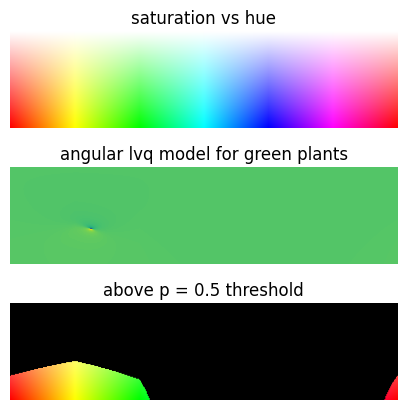

In [10]:
# Check which colors are classified as plants

hue = np.linspace(0, 360, 400, dtype=np.float32)
sat = np.linspace(0, 1, 100, dtype=np.float32)
val = 1 * np.ones((100, 400), dtype=np.float32)
x, y = np.meshgrid(hue, sat)

vals = np.stack((x, y, val), 2)

img = cv2.cvtColor(vals, cv2.COLOR_HSV2RGB)

with torch.no_grad():
    scalar = net.probabilities(torch.from_numpy(img))

scalar = scalar[..., 1].reshape(img.shape[0:2])

fig, axes = plt.subplots(3, 1, figsize=(5,5))
axes[0].imshow(img)
axes[0].set_title('saturation vs hue')
axes[0].set_axis_off()
axes[1].set_title('angular lvq model for green plants')
axes[1].imshow(scalar)
axes[1].set_axis_off()
img[scalar < p_threshold, :] = 0
axes[2].set_title(f'above p = {p_threshold} threshold')
axes[2].imshow(img)
axes[2].set_axis_off();

In [11]:
# Test accuracy on validation dataset

val_dir = '../../Croptimal/resnet/val'
val_class_subdirs = [
    # Class 0
    [('256_class_0', 1.0)],
    # Class 1
    [('256_class_1', 1.0)]]

val_imgs = helper.read_imgs(val_dir, val_class_subdirs)

for i in range(n_classes):
    print(f'Loaded {len(val_imgs[i])} validation images for class {i}')

val_loader = helper.data_loader(val_imgs, minibatch_sz)

total_correct = 0
total_samples = 0
true_positives = 0
false_positives = 0
false_negatives = 0
true_negatives = 0

for batch_nr in range(n_minibatches):
    X, y = next(val_loader)
    X = torch.from_numpy(X)
    y = torch.from_numpy(y)
    
    y_pred = lvq.inference(X)
    total_correct += (y_pred == y).sum().item()
    total_samples += y.shape[0]
    
    # Calculate confusion matrix elements
    true_positives += ((y_pred == 1) & (y == 1)).sum().item()
    false_positives += ((y_pred == 1) & (y == 0)).sum().item()
    false_negatives += ((y_pred == 0) & (y == 1)).sum().item()
    true_negatives += ((y_pred == 0) & (y == 0)).sum().item()

accuracy = total_correct / total_samples
fpr = false_positives / (false_positives + true_negatives) if (false_positives + true_negatives) > 0 else 0
fnr = false_negatives / (false_negatives + true_positives) if (false_negatives + true_positives) > 0 else 0

print(f'Validation accuracy: {accuracy:.4f}')
print(f'False positive rate: {fpr:.4f}')
print(f'False negative rate: {fnr:.4f}')
print(f'TP: {true_positives}, FP: {false_positives}, FN: {false_negatives}, TN: {true_negatives}')

Loaded 458 validation images for class 0
Loaded 288 validation images for class 1
Validation accuracy: 0.5071
False positive rate: 0.4391
False negative rate: 0.5466
TP: 283351, FP: 274414, FN: 341649, TN: 350586
